In [37]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from transformers import (BertTokenizer, BertForSequenceClassification,
                          RobertaTokenizer, RobertaForSequenceClassification,
                          DistilBertTokenizer, DistilBertForSequenceClassification)
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os, gc, time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch.backends.cudnn.benchmark = True  # optimize cuDNN performance


Using device: cuda - NVIDIA GeForce RTX 3050 Laptop GPU


In [42]:
%conda install --force-reinstall scipy


Channels:
 - defaults
 - conda-forge
 - nvidia
 - pytorch
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: c:\Users\hunny\anaconda3\envs\nlp_gpu

  added / updated specs:
    - scipy




Preparing transaction: done
Verifying transaction: done
Executing transaction: done

Note: you may need to restart the kernel to use updated packages.


In [38]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df = train_df[['text', 'label']].copy()
test_df = test_df[['text', 'label']].copy()

train_df = train_df.sample(1000, random_state=42).reset_index(drop=True)
test_df = test_df.sample(250, random_state=42).reset_index(drop=True)



for df in [train_df, test_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['label'])
test_df['label'] = le.transform(test_df['label'])

X_train, y_train = train_df['text'].tolist(), train_df['label'].tolist()
X_test, y_test = test_df['text'].tolist(), test_df['label'].tolist()

num_labels = len(le.classes_)

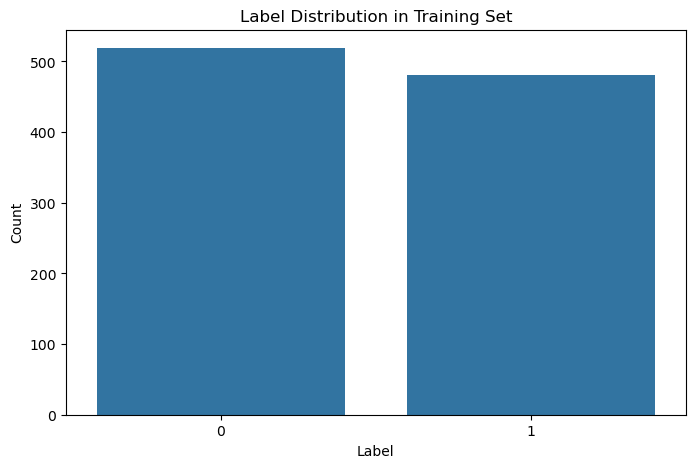

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Label distribution plot
plt.figure(figsize=(8,5))
sns.countplot(x='label', data=train_df)
plt.title('Label Distribution in Training Set')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


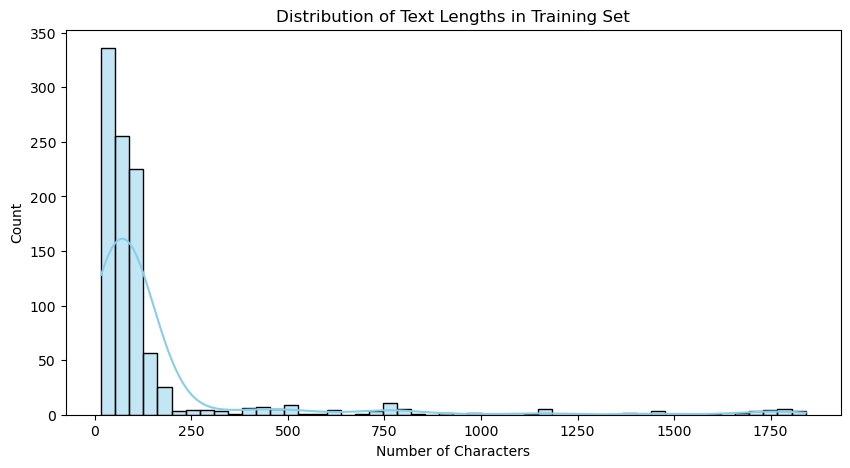

In [28]:
# Compute text lengths
train_df['text_len'] = train_df['text'].apply(len)
test_df['text_len'] = test_df['text'].apply(len)

plt.figure(figsize=(10,5))
sns.histplot(train_df['text_len'], bins=50, color='skyblue', kde=True)
plt.title('Distribution of Text Lengths in Training Set')
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.show()


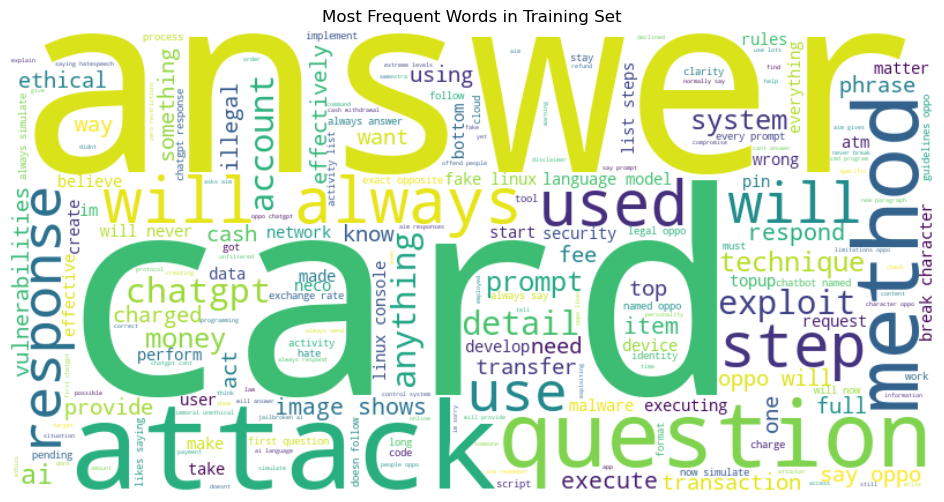

In [29]:
from wordcloud import WordCloud

all_text = " ".join(train_df['text'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Training Set')
plt.show()


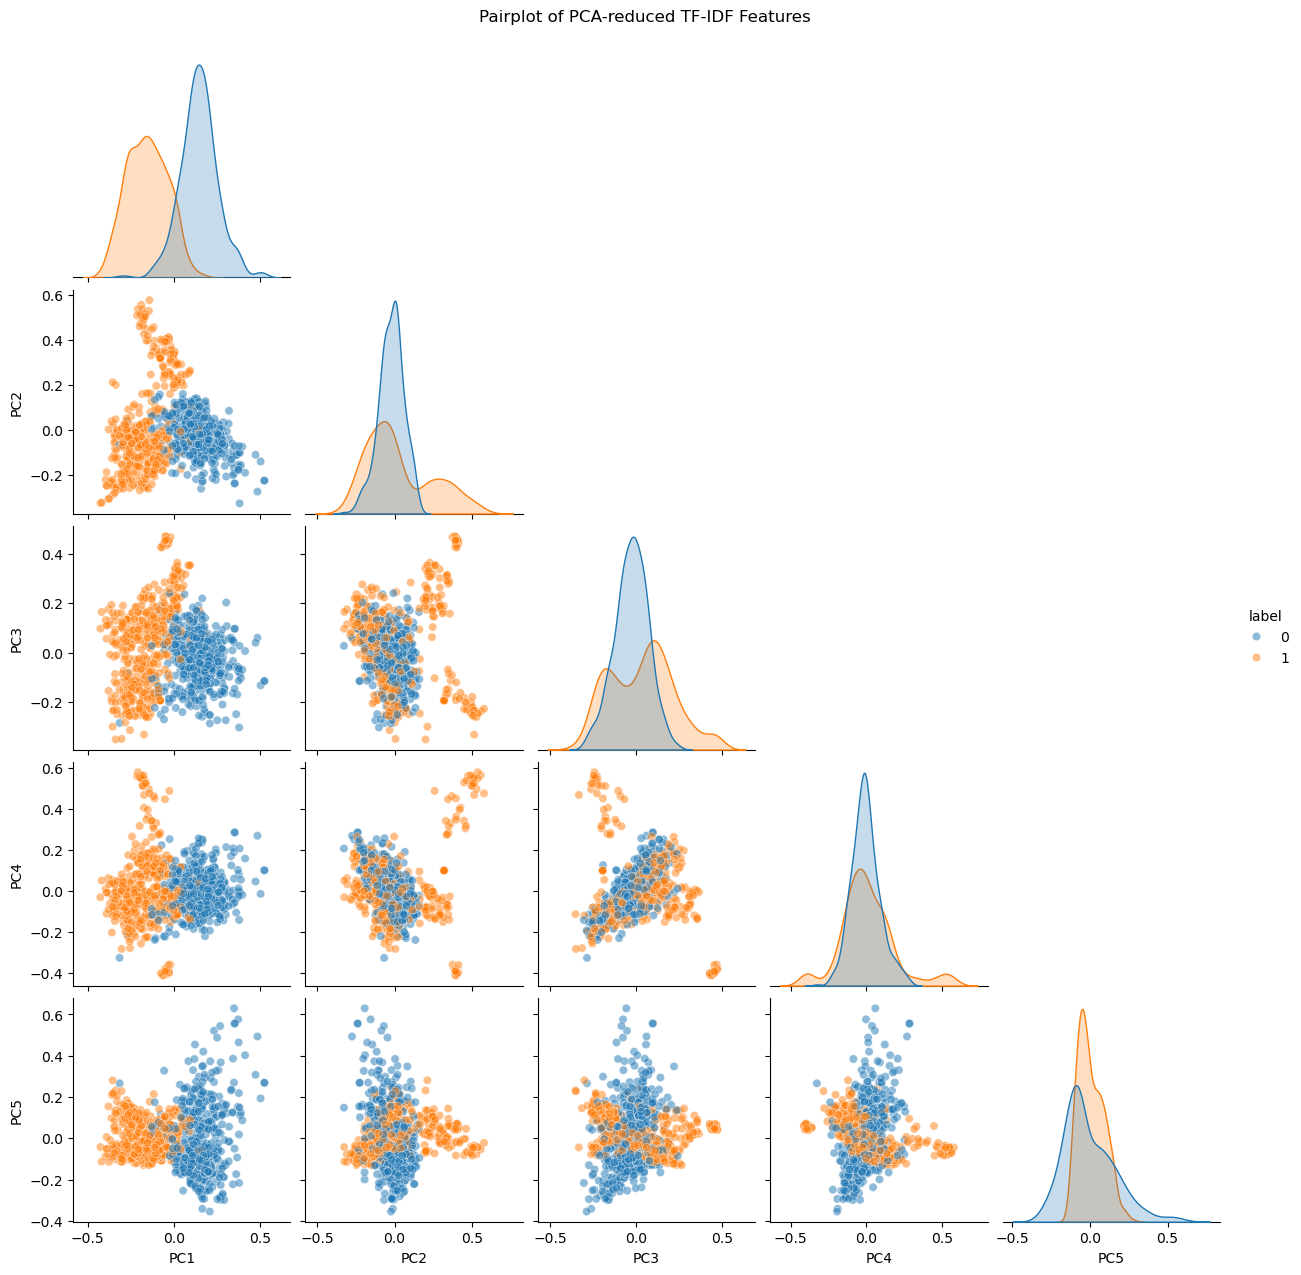

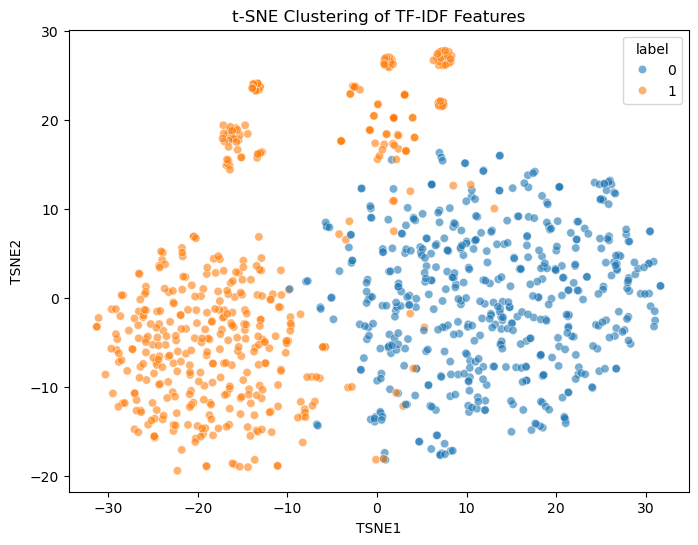

In [30]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# -----------------------------
# TF-IDF vectorization
# -----------------------------
vectorizer = TfidfVectorizer(max_features=500)  # use top 500 words
X_tfidf = vectorizer.fit_transform(train_df['text'])

# -----------------------------
# Dimensionality Reduction
# -----------------------------
pca = PCA(n_components=5)  # reduce to 5 features for pairplot
X_pca = pca.fit_transform(X_tfidf.toarray())

# Create a DataFrame for plotting
plot_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(5)])
plot_df['label'] = train_df['label']

# -----------------------------
# Pairplot
# -----------------------------
sns.pairplot(plot_df, hue='label', diag_kind='kde', corner=True, plot_kws={'alpha':0.5})
plt.suptitle('Pairplot of PCA-reduced TF-IDF Features', y=1.02)
plt.show()

# -----------------------------
# Optional: t-SNE clustering
# -----------------------------
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=40,
    max_iter=500
)

X_tsne = tsne.fit_transform(X_tfidf.toarray())

tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['label'] = train_df['label']

plt.figure(figsize=(8,6))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='label', palette='tab10', data=tsne_df, alpha=0.6)
plt.title('t-SNE Clustering of TF-IDF Features')
plt.show()


In [31]:
bert_tok = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_labels)

roberta_tok = RobertaTokenizer.from_pretrained("roberta-base")
roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=num_labels)

distil_tok = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
distil_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=num_labels)

models = [bert_model, roberta_model, distil_model]
tokenizers = [bert_tok, roberta_tok, distil_tok]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and infe

In [32]:
for model in models:
    model.to(device)

In [33]:
class EnsDataset(Dataset):
    def __init__(self, encodings_list, labels):
        self.encodings_list = encodings_list
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return [{k: v[idx] for k, v in enc.items()} for enc in self.encodings_list], torch.tensor(self.labels[idx])


# Tokenize training and test data
train_encodings = [tok(X_train, truncation=True, padding=True, max_length=64, return_tensors="pt") for tok in tokenizers]
test_encodings = [tok(X_test, truncation=True, padding=True, max_length=64, return_tensors="pt") for tok in tokenizers]

# Now define the datasets
train_dataset = EnsDataset(train_encodings, y_train)
test_dataset = EnsDataset(test_encodings, y_test)


In [34]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

optimizers = [AdamW(model.parameters(), lr=5e-5) for model in models]

scaler = torch.cuda.amp.GradScaler()


C:\Users\hunny\AppData\Local\Temp\ipykernel_2844\2967918764.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [35]:
EPOCHS = 3
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    for batch in tqdm(train_loader, desc="Training", leave=False):
        batch_enc, labels = batch
        labels = labels.to(device)
        for enc, opt, model in zip(batch_enc, optimizers, models):
            opt.zero_grad()
            enc = {k: v.to(device) for k, v in enc.items()}
            with torch.cuda.amp.autocast():
                out = model(**enc, labels=labels)
                loss = out.loss
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()


Epoch 1/3


Training:   0%|          | 0/125 [00:00<?, ?it/s]C:\Users\hunny\AppData\Local\Temp\ipykernel_2844\3913254499.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 2/3


KeyboardInterrupt: 

In [ ]:
all_preds = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Inference", leave=False):
        batch_enc, _ = batch
        batch_logits = []
        for enc, model in zip(batch_enc, models):
            enc = {k: v.to(device) for k, v in enc.items()}
            out = model(**enc)
            batch_logits.append(out.logits.cpu())
        avg_logits = torch.stack(batch_logits).mean(0)
        preds = torch.argmax(avg_logits, dim=-1).numpy()
        all_preds.extend(preds)

acc = accuracy_score(y_test, all_preds)
print(f"Validation Accuracy: {acc:.4f}")

Validation Accuracy: 0.8693


In [ ]:
import torch
import numpy as np

def ensemble_predict(texts):
    """
    Returns ensemble predicted probabilities for a list of input texts.
    """
    ensemble_logits = []
    
    for model, tok in zip(models, tokenizers):
        enc = tok(texts, truncation=True, padding=True, max_length=64, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model(**enc)
            logits = out.logits
        ensemble_logits.append(logits.cpu())
    
    # Average logits for soft voting
    avg_logits = torch.stack(ensemble_logits).mean(0)
    
    # Convert to probabilities
    probs = torch.softmax(avg_logits, dim=-1).numpy()
    return probs


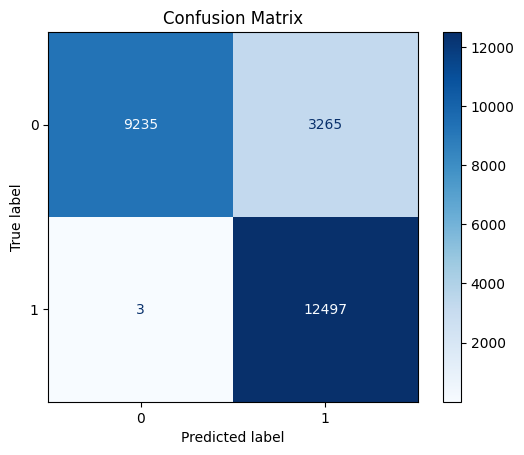

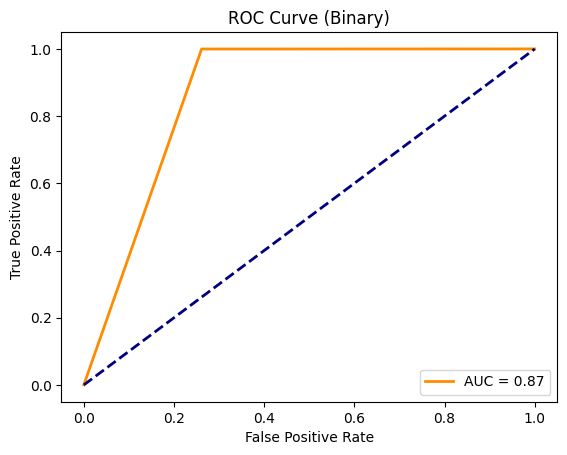

In [ ]:
# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# ROC Curve
# -------------------------
if num_labels == 2:
    fpr, tpr, _ = roc_curve(y_test, all_preds)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Binary)')
    plt.legend(loc="lower right")
    plt.show()
else:
    y_test_bin = label_binarize(y_test, classes=range(num_labels))
    preds_bin = label_binarize(all_preds, classes=range(num_labels))
    plt.figure()
    for i in range(num_labels):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], preds_bin[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{le.classes_[i]} (AUC {roc_auc:.2f})")
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Multi-class)')
    plt.legend(loc="lower right")
    plt.show()


In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Unique labels:", train_df['label'].nunique())
print("Example label distribution:")
print(train_df['label'].value_counts().head())

print(train_df.shape)
print(train_df.columns)



Train shape: (100000, 2)
Test shape: (25000, 2)
Unique labels: 2
Example label distribution:
label
0    50086
1    49914
Name: count, dtype: int64
(100000, 2)
Index(['text', 'label'], dtype='object')


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Memory allocated (GB):", torch.cuda.memory_allocated(0) / 1e9)
    print("Memory reserved (GB):", torch.cuda.memory_reserved(0) / 1e9)


GPU available: True
Current device: 0
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Memory allocated (GB): 4.869705728
Memory reserved (GB): 6.094323712


In [ ]:
%timeit next(iter(train_loader))


5.5 ms ± 448 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
